In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from scipy import stats
import math
from matplotlib.ticker import EngFormatter
from sklearn.linear_model import LinearRegression

In [5]:
hp = pd.read_csv("dataset_2.csv")

In [6]:
hp = hp.dropna()
hp.isnull().sum()

,0
Area_SqFt,0
Rooms,0
Build_Year,0
Location,0
Street_Type,0
Furnishing,0
Property_Type,0
Has_Pool,0
Price,0


In [7]:
l = hp["Location"]
a = l.value_counts()

Text(0, 0.5, 'Properties Count')

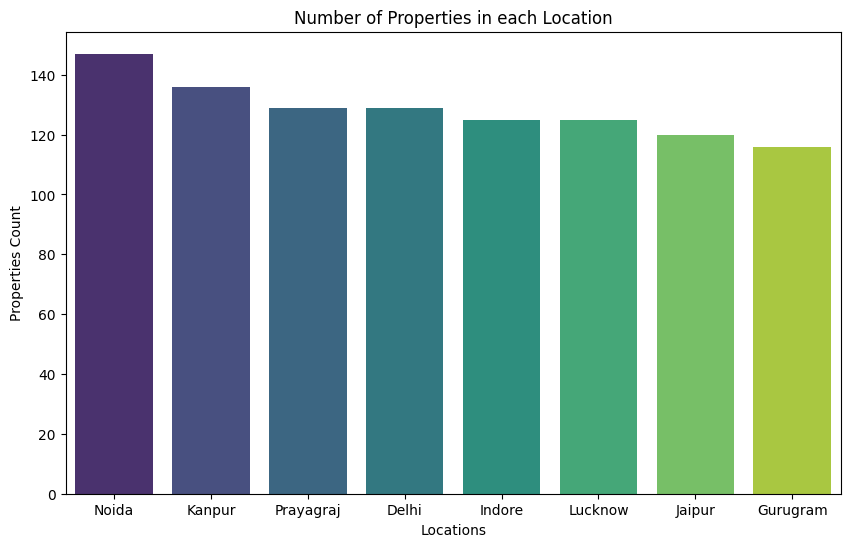

In [8]:
plt.figure(figsize=(10,6))
sns.barplot(x=a.index, y=a.values, hue=a.index, palette='viridis')
plt.title("Number of Properties in each Location")
plt.xlabel('Locations')
plt.ylabel('Properties Count')

Text(0.5, 1.0, 'Number of Furnished Properties in each Location')

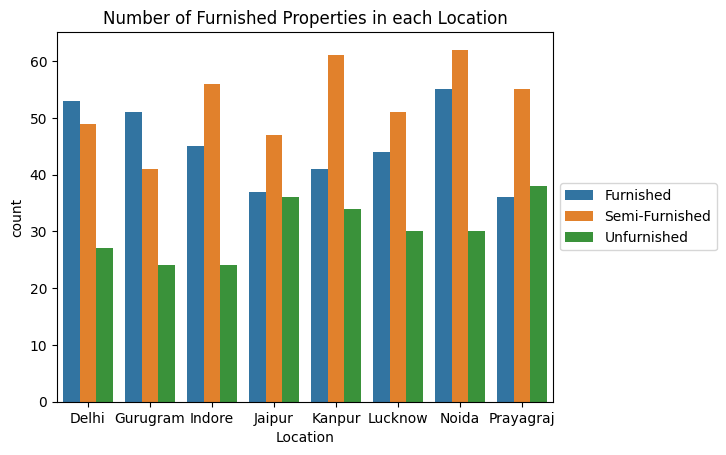

In [9]:
fi = hp.groupby(["Location","Furnishing"]).size()
df = fi.reset_index(name='count')
sns.barplot(df, x="Location", y="count", hue="Furnishing")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("Number of Furnished Properties in each Location")

Text(0.5, 1.0, 'Kind of Properties in each Location')

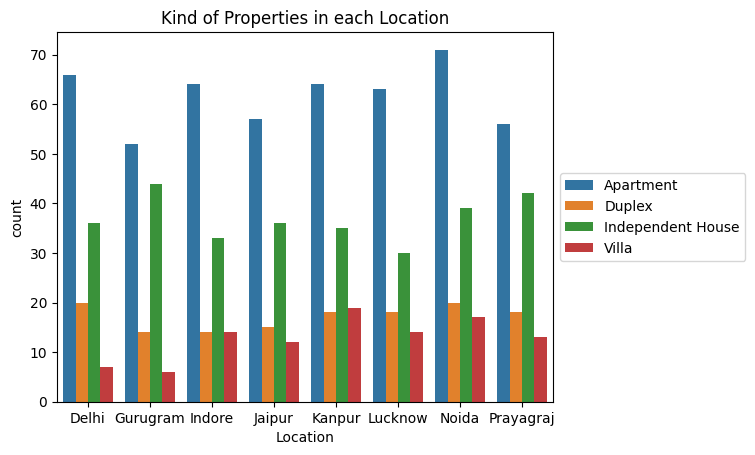

In [10]:
ap = hp.groupby(["Location","Property_Type"]).size()
df = ap.reset_index(name='count')
sns.barplot(df, x="Location", y="count", hue="Property_Type")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("Kind of Properties in each Location")

Text(0.5, 1.0, 'Average Properties Price per Location')

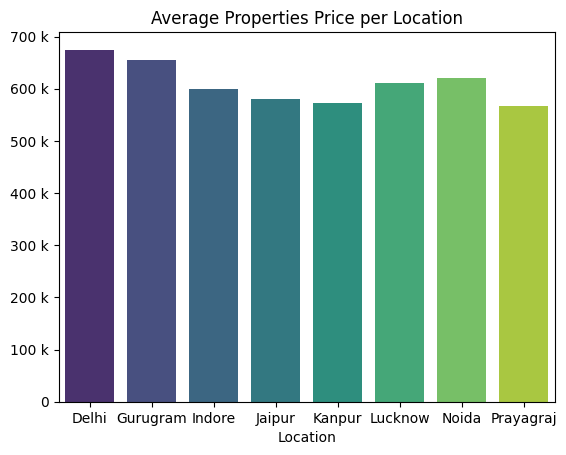

In [11]:
price=hp.groupby("Location")["Price"].mean()

ax = sns.barplot(x=price.index, y=price.values, hue=price.index, palette='viridis')
ax.yaxis.set_major_formatter(EngFormatter())
plt.title("Average Properties Price per Location")

<Axes: xlabel='Area_SqFt', ylabel='Price'>

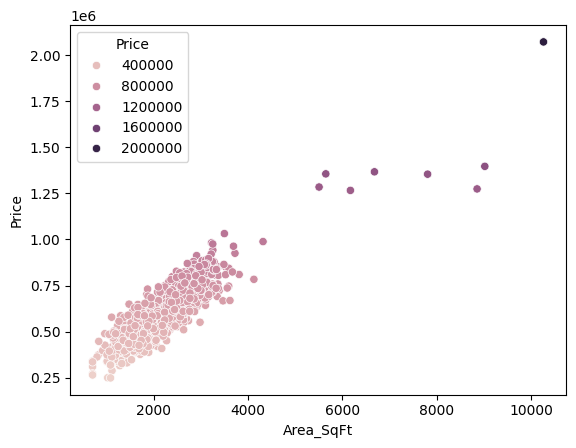

In [12]:
ndf = hp.loc[:,["Area_SqFt","Price"]]
sns.scatterplot(data=ndf, x="Area_SqFt", y="Price", hue="Price")

In [13]:

# Manual Linear Regression with 1 feature
mean_x = ndf.loc[:,"Area_SqFt"].mean()
mean_y = ndf.loc[:,"Price"].mean()

Sxx = ((ndf["Area_SqFt"] - mean_x) ** 2).sum()
Sxy = ((ndf["Area_SqFt"] - mean_x) * (ndf["Price"] - mean_y)).sum()
Syy = ((ndf["Price"] - mean_y) ** 2).sum()

#Slope of the regression
m = Sxy/Sxx
# For each of 1 sqare feet the price increases 0.99
b = mean_y - (m*mean_x)

# Sum of squares of the Regression
SSr = ((((m*ndf["Area_SqFt"]) + b)- mean_y) ** 2).sum()
# Sum of squares Error
SSe = ((ndf["Price"] - ((m*ndf["Area_SqFt"]) + b)) ** 2).sum()


# Cofficent of determination
r2 = SSr/Syy
print(f"{round(r2,2) * 100}% of the variance can be explained my the model")
r = math.sqrt(r2)

if r > 0.7:
    print(f"There is a strong positive correlation: r = {round(r,2)}")
elif r > 0.4:
    print(f"There is a moderate positive correlation: r = {round(r,2)}")
elif r < -0.7:
    print(f"There is a strong negative correlation: r = {round(r,2)}")
else:
    print(f"There is a weak correlation: r = {round(r,2)}")


75.0% of the variance can be explained my the model
There is a strong positive correlation: r = 0.86


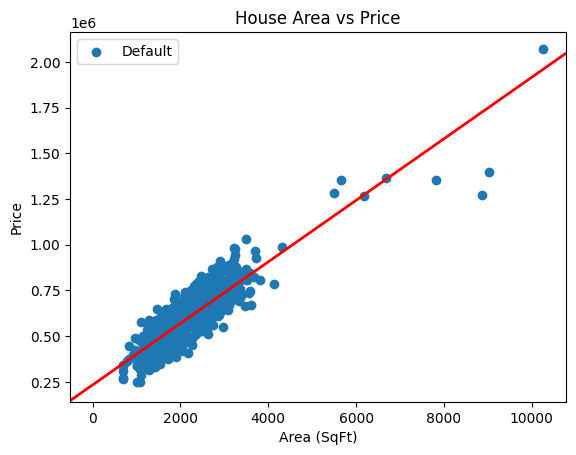

In [14]:
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(x=ndf.Area_SqFt,y=ndf.Price, label="Default");
ax.axline(xy1=(0, b), slope=m, color='r', lw=2)
ax.set_xlabel("Area (SqFt)")
ax.set_ylabel("Price")
ax.set_title("House Area vs Price")
ax.legend()
plt.show()

Text(0.5, 1.0, 'Residual Plot')

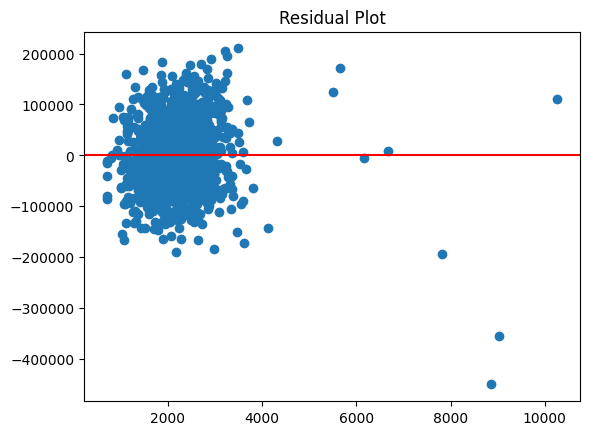

In [15]:
predicted = m * ndf["Area_SqFt"] + b
residuals = ndf["Price"] - predicted

plt.scatter(ndf["Area_SqFt"], residuals)
plt.axhline(y=0, color='r')
plt.title("Residual Plot")

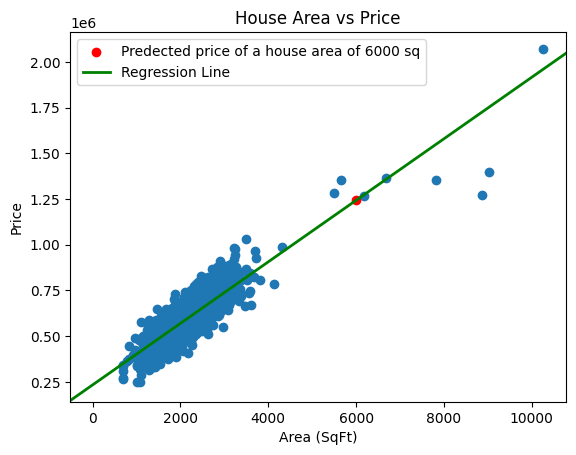

In [16]:
def predict(area):
    price = (m*area)+b
    return price

x = 6000
price = predict(x)

fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(x=ndf.Area_SqFt,y=ndf.Price);
ax.scatter(x, price, c='red',label=f"Predected price of a house area of {x} sq")
ax.axline(xy1=(0, b), slope=m, color='green', lw=2, label="Regression Line")
ax.set_xlabel("Area (SqFt)")
ax.set_ylabel("Price")
ax.set_title("House Area vs Price")
ax.legend()
plt.show()

In [17]:
hp.head()

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0


In [18]:

# Manual Linear Regression with 2 features (Area and #Rooms)
xdf = hp.loc[:,["Area_SqFt","Rooms","Price"]]

x1_mean = xdf['Area_SqFt'].mean()
x2_mean = xdf['Rooms'].mean()
y_mean = xdf['Price'].mean()

Sxx1 =((xdf["Area_SqFt"] - x1_mean)**2).sum()
Sxx2 = ((xdf["Rooms"] - x2_mean)**2).sum()
Syy = ((xdf["Price"] - y_mean)**2).sum()

Sxy1 = ((xdf["Area_SqFt"] - x1_mean) * (xdf["Price"] - y_mean)).sum()
Sxy2 = ((xdf["Rooms"] - x2_mean) * (xdf["Price"] - y_mean)).sum()


X = xdf[["Area_SqFt", "Rooms"]].values
y = xdf["Price"].values
ones = np.ones((len(X), 1))
X = np.hstack((ones, X))
TX = X.T @ X
a = np.linalg.inv(TX)
b = X.T @ y
c = a @ b

m1 = c[1]
b = c[0]
m2 = c[2]


SRR = ((((m1*xdf["Area_SqFt"]) + (m2*xdf["Rooms"]) + b) - y_mean)**2).sum()
SSE = (( xdf["Price"]- ((m1*xdf["Area_SqFt"]) + (m2*xdf["Rooms"]) + b) )**2).sum()

r2  = SRR/Syy
r = math.sqrt(r2)
print(f"{round(r2,2) * 100}% of the variance can be explained my the model")

if r > 0.7:
    print(f"There is a strong positive correlation: r = {round(r,2)}")
elif r > 0.4:
    print(f"There is a moderate positive correlation: r = {round(r,2)}")
elif r < -0.7:
    print(f"There is a strong negative correlation: r = {round(r,2)}")
else:
    print(f"There is a weak correlation: r = {round(r,2)}")

78.0% of the variance can be explained my the model
There is a strong positive correlation: r = 0.89


In [19]:
def predict1(area,room):
    price = (m1*area) + (m2*room)+b
    return price

x = 6000
x2 = 4
price = predict1(x,x2)

print(price)

1230172.6462317184


In [20]:
# Multiple Regression with sklearn
model = LinearRegression()
model.fit(xdf[["Area_SqFt","Rooms"]], xdf["Price"])


print("Sklearn b₀:", model.intercept_)
print("Sklearn b₁, b₂:", model.coef_)

print("Your b₀:", c[0])
print("Your b₁, b₂:", c[1], c[2])

Sklearn b₀: 158065.0950445492
Sklearn b₁, b₂: [  167.46347317 16831.67803796]
Your b₀: 158065.09504454734
Your b₁, b₂: 167.46347317255697 16831.67803795724


In [21]:
# Predictions Interval Practice using t-distrubution
n = 25

sample = ndf.sample(n=n, random_state=1)
std = sample["Area_SqFt"].std()
mean_x = sample["Area_SqFt"].mean()
mean_y = sample["Price"].mean()


Sxx = ((sample["Area_SqFt"] - mean_x) ** 2).sum()
Sxy = ((sample["Area_SqFt"] - mean_x) * (sample["Price"] - mean_y)).sum()
Syy = ((sample["Price"] - mean_y) ** 2).sum()

m = Sxy/Sxx
b = mean_y - (m*mean_x)
t = stats.t.ppf(0.975, n-2)


SSe = ((sample["Price"] - ((m*sample["Area_SqFt"]) + b)) ** 2).sum()
nx = 6000
ny = (m*nx) + b
se =  math.sqrt(SSe/(n-2))
def compute(mean,std,se,sxx,x,y, n):
  first = math.sqrt(1 + 1/n + (((nx-mean)**2) / sxx))
  h  = ny + t * (se *first)
  l  = ny - t * (se *first)

  print(l,h)

compute(mean_x,std,se,Sxx,nx,ny,n)
print(ny)

1294119.2516083494 1710324.8448820636
1502222.0482452065


In [22]:
import statsmodels.api as sm

sample = ndf.sample(n=25, random_state=1)

X = sm.add_constant(sample["Area_SqFt"])  # Adds the intercept column
model = sm.OLS(sample["Price"], X).fit()

nx = 6000

new_obs = np.array([[1, nx]])  # [Intercept, Area_SqFt]

predictions = model.get_prediction(new_obs)
pred_interval = predictions.summary_frame(alpha=0.05)

print(pred_interval[["mean", "obs_ci_lower", "obs_ci_upper"]])

           mean  obs_ci_lower  obs_ci_upper
0  1.502222e+06  1.294119e+06  1.710325e+06


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(xdf[["Area_SqFt","Rooms"]], xdf["Price"], test_size=1/3)
X_train
model = LinearRegression()
model.fit(X_train, Y_train.to_frame())
result = model.score(X_test, Y_test.to_frame())
print("r^2: %.3f" % result)

r^2: 0.804
